# FairFace Inference Demo

## Imports

In [ ]:
import torch
import matplotlib.pyplot as plt

from PIL import Image

from fairface_vit import FairFaceViT

from model.siglip import model as siglip_model, processor as siglip_processor
from model.clip   import model as clip_model,   processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor

## Class Labels

In [ ]:
gender_class = ["Male", "Female"]

age_class = ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49",
              "50-59", "60-69", "more than 70"]

race_class = ["East Asian", "Indian", "Black", "White", "Middle Eastern",
               "Latino_Hispanic", "Southeast Asian"]

## Helper Functions

In [ ]:
def get_logits(model, processor, image, model_name, device):
    
    # LOAD THE MODEL
    
    checkpoint = torch.load(
        f"../checkpoints/{model_name}/{model_name}-best-heads.pt",
        map_location=device
    )

    model.gender.load_state_dict(
        checkpoint["gender_head"]
    )

    model.age.load_state_dict(
        checkpoint["age_head"]
    )

    model.race.load_state_dict(
        checkpoint["race_head"]
    )

    model.to(device)
    model.eval()

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values)

    # LOGITS
    return {
        'gender': outputs["gender"],
        'age': outputs["age"],
        'race': outputs["race"]
        }


# display the probabilities of a class, will be used inside the 'display_prediction' function
def print_ranked(category, class_names, probabilities):
    print(f"\n{category}:")

    pairs = []
    for i in range(len(class_names)):
        name = class_names[i]
        prob = probabilities[i]
        pairs.append((name, prob))

    pairs.sort(key=lambda pair: pair[1], reverse=True)


    for pair in pairs:
        name = pair[0]
        prob = pair[1]
        percentage = prob * 100
        print(f"  {name:<20}: {percentage:.2f}%")

    top_pair = pairs[0]
    top_name = top_pair[0]

    print(f"  -> Prediction: {top_name}")

    return top_name



def display_prediction(logits,name=None):
    if name is not None:
        model_name = name
        
    gender_prob = torch.sigmoid(logits['gender']).item()
    gender_probs = [1 - gender_prob, gender_prob]  # 0 -> Male, 1 -> Female

    age_probs  = torch.softmax(logits['age'], dim=1)[0].cpu().tolist()
    race_probs = torch.softmax(logits['race'], dim=1)[0].cpu().tolist()
    
    # print("=" * 45)
    print(f"{"-"*5}{model_name} Prediction Result{"-"*5}")
    # print("=" * 45)

    predictions = {
        "Gender": print_ranked("Gender", gender_class, gender_probs),
        "Age":    print_ranked("Age", age_class, age_probs),
        "Race":   print_ranked("Race", race_class, race_probs),
    }

    print("\n\n")
    return predictions

## Load The Model

In [4]:
fairface_siglip_model = FairFaceViT(siglip_model)
fairface_clip_model   = FairFaceViT(clip_model)
fairface_dinov2_model = FairFaceViT(dinov2_model)

## Load Image

In [5]:
image = Image.open("../test-images/test.jpg").convert("RGB")



## Result

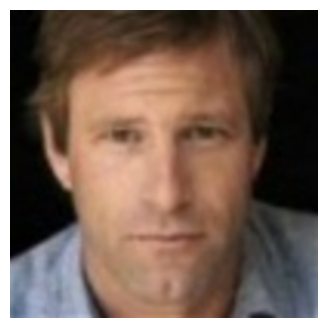

-----CLIP Prediction Result-----

Gender:
  Male                : 99.24%
  Female              : 0.76%
  -> Prediction: Male

Age:
  40-49               : 57.40%
  30-39               : 19.98%
  50-59               : 17.07%
  20-29               : 2.79%
  10-19               : 2.30%
  60-69               : 0.27%
  3-9                 : 0.11%
  more than 70        : 0.04%
  0-2                 : 0.03%
  -> Prediction: 40-49

Race:
  White               : 85.52%
  Black               : 4.45%
  Middle Eastern      : 3.47%
  Latino_Hispanic     : 2.55%
  Indian              : 2.42%
  Southeast Asian     : 0.83%
  East Asian          : 0.75%
  -> Prediction: White



-----SIGLIP Prediction Result-----

Gender:
  Male                : 98.72%
  Female              : 1.28%
  -> Prediction: Male

Age:
  40-49               : 53.23%
  30-39               : 34.70%
  20-29               : 7.70%
  50-59               : 3.79%
  10-19               : 0.54%
  60-69               : 0.02%
  3-9         

{'Gender': 'Male', 'Age': '40-49', 'Race': 'White'}

In [6]:
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.axis('off')
plt.show()

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_logits = get_logits(fairface_clip_model, clip_processor, image,'clip', device)
display_prediction(clip_logits,'CLIP')

siglip_logits = get_logits(fairface_siglip_model, siglip_processor, image,'siglip', device)
display_prediction(siglip_logits,'SIGLIP')

dinov2_logits = get_logits(fairface_dinov2_model, dinov2_processor, image,'dinov2', device)
display_prediction(dinov2_logits,'DINOV2')